In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import anndata
import seaborn as sns 
import pandas as pd
import scanpy as sc

from readcount_tools import PAPER_CONTEXT, PAGEWIDTH_IN, SMALL_SIZE,MEDIUM_SIZE,BIGGER_SIZE,LINEWIDTH,POINTSIZE,TICKLENGTH,LEGEND_FONTSIZE,SPINEWIDTH,LETTER_LOC_X,LETTER_LOC_Y

from sklearn import linear_model
from readcount_tools import compute_gene_stats

In [2]:
basepath = 'data/tasic/'

In [3]:
adata_single_cluster = anndata.read_h5ad(f'{basepath}adata_single_cluster.h5ad')
print(adata_single_cluster.uns['clustername'],adata_single_cluster.shape)

L6 IT VISp Penk Col27a1 (1049, 33914)


In [4]:
ncols = 2
nrows = 2
panelheight = PAGEWIDTH_IN/ncols/2
figheight_in = panelheight*nrows

In [5]:
def plot_estimate_alpha(ad,ax,mean_varkey,FF_varkey,q,yticks=[200,400],bins=None):
    
    FF = ad.var[FF_varkey]
    mean = ad.var[mean_varkey]
    
    #ignoring large outlier FFs and genes with mean<1
    large_FF_cutoff = np.percentile(FF,q=q)
    
    if bins is None:
        xmax = int(np.round(large_FF_cutoff/100)*100)
        bins = np.linspace(0,xmax,num=101)
        
    else:
        xmax=np.max(bins)
    print(f'{FF_varkey}: bins until {xmax} (to cut off FF>{q}-th percentile={large_FF_cutoff:.1f})')
    
    mean_larger_1_idx = mean > 1
    
    
    bincounts,bins,_ = ax.hist(FF[mean_larger_1_idx],bins=bins,histtype='stepfilled')
    ax.set_yticks(yticks)
    binwidth = np.unique(np.diff(bins))
    assert len(binwidth==1)
    binwidth = binwidth[0]

    top_bin_idx = np.argmax(bincounts)
    top_bin_val = bincounts[top_bin_idx]
    top_bin_lowlim = bins[top_bin_idx]
    top_bin_center = top_bin_lowlim + 0.5*binwidth

    ax.vlines(x=top_bin_center,ymin=0,ymax=top_bin_val*0.92,colors='tab:red',label='Estimated\n' fr'$\alpha_Z = ${int(top_bin_center)}',lw=LINEWIDTH)
    ax.legend(frameon=False,fontsize=LEGEND_FONTSIZE)

    ax.set_ylabel('Number of genes')
    ax.set_xlim(0,xmax)
    return bins

In [6]:
def plot_estimate_ez(ad,ax,mean_varkey,fraczero_varkey,xmin=0.1,xmax=200,yticks=[-1,-5]):
    
    
    x=ad.var[mean_varkey].values
    y=ad.var[fraczero_varkey].values
    frac_zero_0_idx = y==0
    mean_larger_1_idx = (ad.var[mean_varkey].values < xmax) & (ad.var[mean_varkey].values > xmin)

    x = x[~frac_zero_0_idx & mean_larger_1_idx]
    y = y[~frac_zero_0_idx & mean_larger_1_idx]

    xmax_fit=xmax
    
    logy=np.log(y)

    lm = linear_model.LinearRegression(fit_intercept=False)
    lm.fit(x.reshape(-1, 1),logy)
    slope = lm.coef_[0]

    ax.scatter(x,logy,s=POINTSIZE,lw=0,rasterized=True)

    x_fit = np.arange(0,xmax_fit)
    y_fit = slope*x_fit

    E_Z = 1/(-slope)

    ax.plot(x_fit,y_fit,'k',label=r'$E_Z$ = -1/slope = ' f'{E_Z:.1f}',lw=LINEWIDTH)
    ax.set_yticks(yticks)
    leg=ax.legend(frameon=True,fontsize=LEGEND_FONTSIZE)
    leg.get_frame().set_linewidth(0.0)
    ax.set_ylabel('log(fraction of zeros)')
    # plt.xscale('log')

gene_FF_withinCluster: bins until 200 (to cut off FF>99-th percentile=189.6)
gene_FF_allCells: bins until 500 (to cut off FF>95-th percentile=487.9)


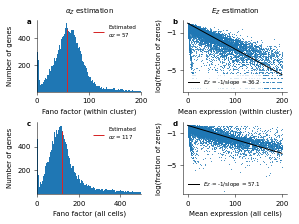

In [7]:
path='figures/S_tasic_estimate_alpha_eZ.pdf'
with mpl.rc_context(PAPER_CONTEXT):
    
    fig,axes = plt.subplots(2,2,figsize=(PAGEWIDTH_IN*0.66,figheight_in))
    
    
    ### ALPHA ESTIMATION
    plot_estimate_alpha(ad=adata_single_cluster,ax=axes[0,0],mean_varkey='gene_mean_withinCluster',FF_varkey='gene_FF_withinCluster',q=99)
    axes[0,0].set_title(r'$\alpha_Z$' ' estimation')
    axes[0,0].set_xlabel('Fano factor (within cluster)')
    plot_estimate_alpha(ad=adata_single_cluster,ax=axes[1,0],mean_varkey='gene_mean_allCells',FF_varkey='gene_FF_allCells',q=95)
    axes[1,0].set_xlabel('Fano factor (all cells)')
    
    ### E[Z] ESTIMATION
    plot_estimate_ez(ad=adata_single_cluster,ax=axes[0,1],mean_varkey='gene_mean_withinCluster',fraczero_varkey='gene_fraction_zeros_withinCluster')
    axes[0,1].set_title(r'$E_Z$' ' estimation')
    axes[0,1].set_xlabel('Mean expression (within cluster)')
    plot_estimate_ez(ad=adata_single_cluster,ax=axes[1,1],mean_varkey='gene_mean_allCells',fraczero_varkey='gene_fraction_zeros_allCells')
    axes[1,1].set_xlabel('Mean expression (all cells)')
    
    sns.despine()
    
    
    for ax in axes.flatten():
        for axis in ['bottom','left']:
            ax.spines[axis].set_linewidth(SPINEWIDTH)
    
    plt.tight_layout()
    
    letters=['a','b',
             'c','d',]
    for ax,letter, in zip(axes.flatten(),letters):
        ax.text(LETTER_LOC_X+0.2,LETTER_LOC_Y,letter,transform=ax.transAxes,fontweight='bold')

    
    fig.savefig(path, dpi=300, format=None, bbox_inches = 'tight', pad_inches = 0)

In [8]:
#load simulated readcounts
ad_sim = anndata.read_h5ad('data/tasic/simulations/adata_sim_tpm.h5ad')
print(ad_sim.shape)
#note that .X still holds readcounts, umi and TPM counts are in separate layers
print(ad_sim.layers)

#compute stats on simulated data for all cells
compute_gene_stats(ad_sim,suffix='allCells')

#subset to example cluster
clusters,clustercounts = np.unique(ad_sim.obs.clusters,return_counts=True)
# example cluster is the 2nd largest
example_cluster_id = np.argsort(-clustercounts)[1]
#show that obs numbers match
print(adata_single_cluster.shape)
ad_sim_singlecluster = ad_sim[ad_sim.obs.clusters==example_cluster_id].copy()
print(ad_sim_singlecluster.shape)

#filter genes as for real single cluster data and compute stats
sc.pp.filter_genes(ad_sim_singlecluster,min_cells=1)
compute_gene_stats(ad_sim_singlecluster,suffix='withinCluster')
print(ad_sim_singlecluster.shape)

tcmalloc: large alloc 5364908032 bytes == 0x48068000 @ 


(23822, 28151)
Layers with keys: tpm, umis_sim


tcmalloc: large alloc 2682454016 bytes == 0x1dff68000 @ 
tcmalloc: large alloc 2682454016 bytes == 0x27fd98000 @ 


(1049, 33914)
(1049, 28151)
(1049, 17845)


gene_FFwithinCluster: bins until 400 (to cut off FF>99-th percentile=371.9)
gene_FFallCells: bins until 500 (to cut off FF>95-th percentile=468.7)


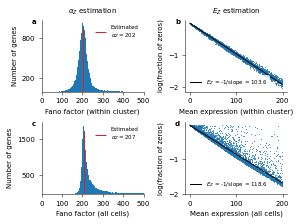

In [9]:
path='figures/S_tasic_estimate_alpha_eZ_simulation2.pdf'
with mpl.rc_context(PAPER_CONTEXT):
    
    fig,axes = plt.subplots(2,2,figsize=(PAGEWIDTH_IN*0.66,figheight_in))
    
    
    ### ALPHA ESTIMATION
    plot_estimate_alpha(ad=ad_sim_singlecluster,ax=axes[0,0],mean_varkey='gene_meanwithinCluster',FF_varkey='gene_FFwithinCluster',q=99,yticks=[200,800])
    axes[0,0].set_xticks([0,100,200,300,400,500])
    axes[0,0].set_title(r'$\alpha_Z$' ' estimation')
    axes[0,0].set_xlabel('Fano factor (within cluster)')
    plot_estimate_alpha(ad=ad_sim_singlecluster,ax=axes[1,0],mean_varkey='gene_meanallCells',FF_varkey='gene_FFallCells',q=95,yticks=[500,1500])
    axes[1,0].set_xticks([0,100,200,300,400,500])
    axes[1,0].set_xlabel('Fano factor (all cells)')
    
    ### E[Z] ESTIMATION
    plot_estimate_ez(ad=ad_sim_singlecluster,ax=axes[0,1],mean_varkey='gene_meanwithinCluster',fraczero_varkey='gene_fraction_zeroswithinCluster',yticks=[-1,-2])
    axes[0,1].set_title(r'$E_Z$' ' estimation')
    axes[0,1].set_xlabel('Mean expression (within cluster)')
    plot_estimate_ez(ad=ad_sim_singlecluster,ax=axes[1,1],mean_varkey='gene_meanallCells',fraczero_varkey='gene_fraction_zerosallCells',yticks=[-1,-2])
    axes[1,1].set_xlabel('Mean expression (all cells)')
    
    sns.despine()
    
    
    for ax in axes.flatten():
        for axis in ['bottom','left']:
            ax.spines[axis].set_linewidth(SPINEWIDTH)
    
    plt.tight_layout()
    
    letters=['a','b',
             'c','d',]
    for ax,letter, in zip(axes.flatten(),letters):
        ax.text(LETTER_LOC_X+0.2,LETTER_LOC_Y,letter,transform=ax.transAxes,fontweight='bold')

    
    fig.savefig(path, dpi=300, format=None, bbox_inches = 'tight', pad_inches = 0)